# Khám Phá Dữ Liệu Airbnb New York (NYC 2019) — Trực Quan Hóa Dễ Hiểu
**Tập dữ liệu:** `AB_NYC_2019-clean.csv` (48,884 phòng cho thuê đã được làm sạch)  
**Mục tiêu tài liệu:** Giúp người đọc dễ dàng nắm bắt bức tranh toàn cảnh về thị trường Airbnb tại New York qua các câu hỏi thực tế:
- Phòng tập trung ở những khu vực nào?
- Giá thuê trung bình bao nhiêu tiền một đêm? Quận nào đắt nhất, quận nào rẻ nhất?
- Thuê căn hộ nguyên căn hay phòng riêng thì tiết kiệm hơn?
- Những khu phố nào sôi động và có nhiều lựa chọn nhất?
- Ai đang là chủ nhà trên Airbnb: người dân chia sẻ phòng hay các đơn vị kinh doanh chuyên nghiệp?

Mỗi biểu đồ đều được vẽ **gọn gàng, dễ nhìn** và có **phần giải thích ý nghĩa thực tế ngay bên dưới**.

## 0. Thiết lập Môi trường & Bảng Màu
Chuẩn bị các thư viện đồ họa cơ bản và bảng màu hài hòa, chữ to rõ ràng giúp các biểu đồ dễ đọc nhất.

In [1]:
import sys
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Thiết lập phong cách hiển thị sạch sẽ, chữ to rõ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110

# Bảng màu đại diện cho 5 quận
BOROUGH_COLORS = {
    'Manhattan': '#2b5c8f',      # Xanh dương đậm
    'Brooklyn': '#e07a5f',       # Cam đất
    'Queens': '#81b29a',         # Xanh ngọc dịu
    'Bronx': '#f2cc8f',          # Vàng cát
    'Staten Island': '#9d8189'   # Hồng xám
}

print("Đã sẵn sàng tạo biểu đồ!")

Đã sẵn sàng tạo biểu đồ!


## 1. Đọc Dữ liệu Đã Làm Sạch
Tải tệp dữ liệu `AB_NYC_2019-clean.csv` vào bộ nhớ và xem thử vài dòng đầu tiên.

In [2]:
df = pd.read_csv("AB_NYC_2019-clean.csv")
print(f"Tổng số phòng khảo sát: {len(df):,} phòng")
df[['name', 'neighbourhood_group', 'room_type', 'price', 'number_of_reviews']].head(3)

Tổng số phòng khảo sát: 48,884 phòng


,name,neighbourhood_group,room_type,price,number_of_reviews
0,Clean & quiet apt home by the park,Brooklyn,Private room,149,9
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225,45
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150,0


## 2. Các phòng Airbnb ở New York tập trung ở những quận nào?
Chúng ta cùng xem số lượng và tỷ lệ phần trăm phòng trọ phân bố giữa 5 quận lớn của New York.

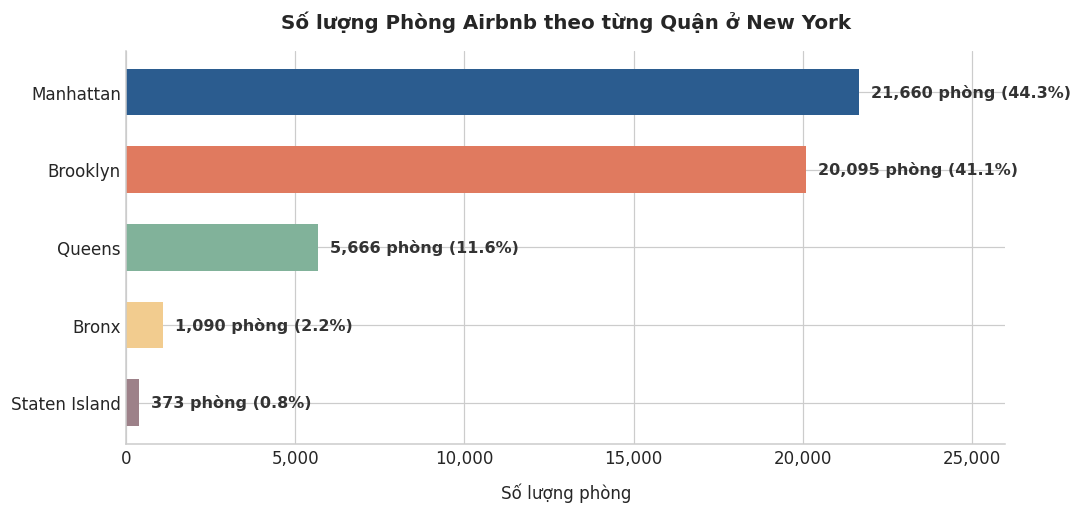

In [3]:
borough_counts = df['neighbourhood_group'].value_counts()
borough_pct = (borough_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = [BOROUGH_COLORS.get(b, '#333333') for b in borough_counts.index]

bars = ax.barh(borough_counts.index[::-1], borough_counts.values[::-1], color=colors[::-1], height=0.6)

# Hiển thị số lượng và % trên từng cột
for bar, pct in zip(bars, borough_pct.values[::-1]):
    w = bar.get_width()
    ax.text(w + 350, bar.get_y() + bar.get_height()/2, 
            f"{int(w):,} phòng ({pct}%)", 
            va='center', ha='left', fontsize=10.5, fontweight='bold', color='#333333')

ax.set_title("Số lượng Phòng Airbnb theo từng Quận ở New York", pad=15)
ax.set_xlabel("Số lượng phòng", labelpad=10)
ax.set_xlim(0, max(borough_counts.values) * 1.2)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận xét Thực tế:
> - **Nội dung biểu đồ:** Biểu đồ thể hiện số lượng phòng cho thuê tại 5 quận của thành phố New York (Manhattan, Brooklyn, Queens, Bronx, Staten Island).
> - **Điểm nổi bật nhất:**
>   - **Manhattan** (21,660 phòng ~ 44.3%) và **Brooklyn** (20,095 phòng ~ 41.1%) chiếm tới **hơn 85%** toàn bộ thị trường.
>   - **Queens** đứng thứ 3 với khoảng 11.6% (5,666 phòng).
>   - **Bronx** (2.2%) và **Staten Island** (0.8%) có rất ít phòng cho thuê.
> - **Lời khuyên thực tế:**
>   - Khách du lịch đến New York tìm phòng thì **Manhattan và Brooklyn** có nguồn cung dồi dào nhất, phong phú nhất về mức giá và vị trí.
>   - Nếu đến Bronx hay Staten Island, bạn nên đặt phòng từ sớm vì số lượng chỗ ở rất hạn chế.

## 3. Khách thuê có những loại phòng nào để lựa chọn?
Xem tỷ lệ giữa 3 loại phòng chính: Căn hộ nguyên căn (Entire home/apt), Phòng ngủ riêng (Private room), và Phòng ở ghép (Shared room).

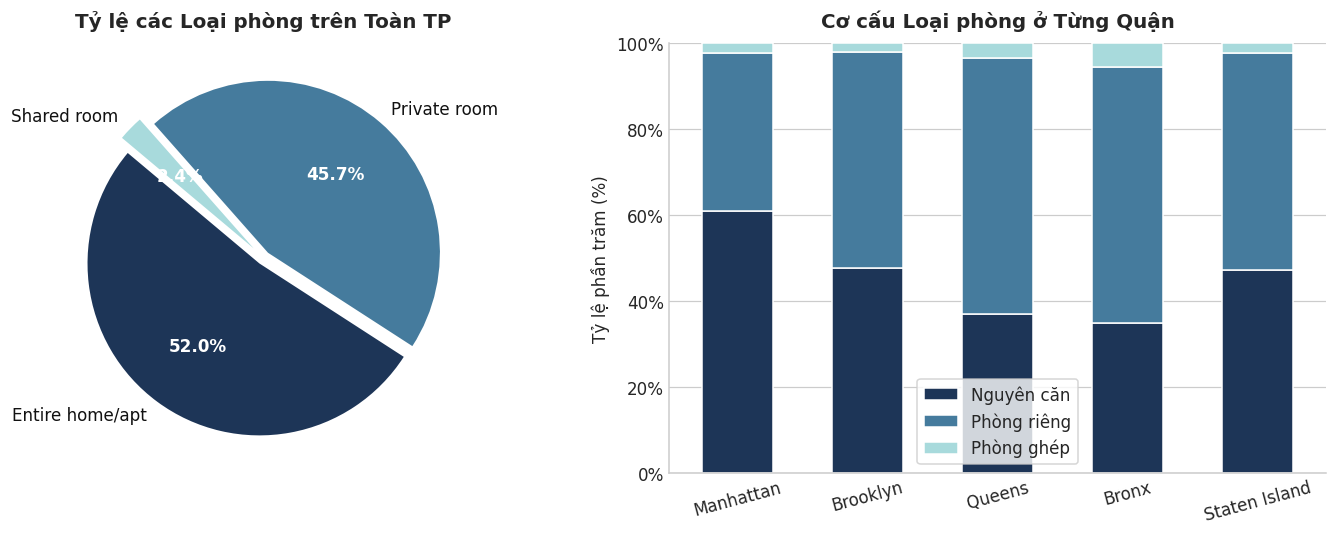

In [4]:
room_counts = df['room_type'].value_counts()
room_pct = (room_counts / len(df) * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Biểu đồ tròn thể hiện tỷ lệ %
room_colors = ['#1d3557', '#457b9d', '#a8dadc']
wedges, texts, autotexts = ax1.pie(
    room_counts, labels=room_counts.index, autopct='%1.1f%%',
    startangle=140, colors=room_colors, explode=(0.04, 0.04, 0.08),
    textprops=dict(color="#111111", fontsize=11)
)
for at in autotexts:
    at.set_color('white')
    at.set_weight('bold')
ax1.set_title("Tỷ lệ các Loại phòng trên Toàn TP", pad=10)

# Biểu đồ cột thể hiện theo từng quận
room_by_b = pd.crosstab(df['neighbourhood_group'], df['room_type'], normalize='index') * 100
room_by_b = room_by_b.loc[['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']]

room_by_b.plot(kind='bar', stacked=True, color=room_colors, ax=ax2, width=0.55, edgecolor='white')
ax2.set_title("Cơ cấu Loại phòng ở Từng Quận", pad=10)
ax2.set_xlabel("")
ax2.set_ylabel("Tỷ lệ phần trăm (%)")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.legend(['Nguyên căn', 'Phòng riêng', 'Phòng ghép'], frameon=True, facecolor='white')
ax2.tick_params(axis='x', rotation=15)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận xét Thực tế:
> - **Nội dung biểu đồ:** Cho biết khách du lịch chuộng thuê hình thức nào và mỗi quận có thế mạnh về loại phòng nào.
> - **Điểm nổi bật nhất:**
>   - **Căn hộ nguyên căn** chiếm đa số với **52.0%**, kế tiếp là **Phòng riêng** với **45.7%**.
>   - **Phòng ở ghép (Shared room)** chỉ chiếm vỏn vẹn **2.4%** (rất hiếm).
>   - Riêng tại **Manhattan**, hơn **63%** là căn hộ nguyên căn phục vụ khách du lịch và người đi công tác. Ngược lại, tại **Queens và Bronx**, đa số phòng cho thuê là **phòng riêng trong nhà dân** (chiếm gần 60%).
> - **Lời khuyên thực tế:**
>   - Đi nhóm đông người hoặc gia đình cần sự riêng tư: Manhattan và Brooklyn có rất nhiều căn hộ nguyên căn tiện nghi.
>   - Đi du lịch một mình hoặc muốn tiết kiệm: Thuê phòng riêng tại Queens hoặc Brooklyn vừa rẻ, vừa dễ tìm.

## 4. Giá thuê phòng phổ biến nhất ở New York là bao nhiêu?
Tìm hiểu mức giá thực tế mà đa số mọi người chi trả cho một đêm nghỉ tại New York.

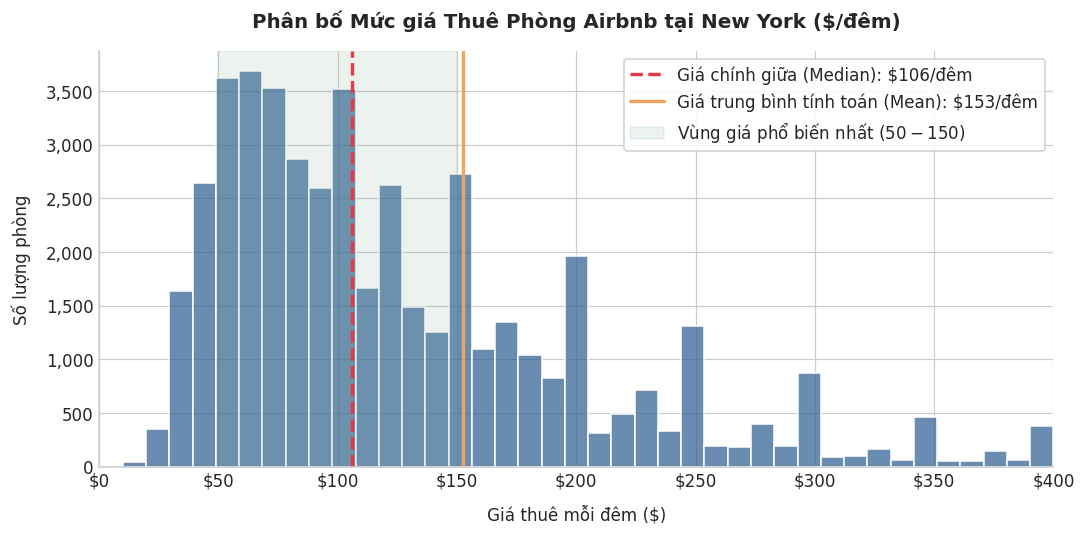

-> Có 69.4% số phòng có giá từ $150/đêm trở xuống.
-> Có 82.8% số phòng có giá từ $200/đêm trở xuống.


In [5]:
# Lọc mức giá phổ biến dưới $400 để nhìn rõ đa số phòng
popular_prices = df[df['price'] <= 400]['price']
median_val = df['price'].median()
mean_val = df['price'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(popular_prices, bins=40, color='#2b5c8f', edgecolor='white', alpha=0.7, ax=ax)

# Đánh dấu các mốc giá quan trọng
ax.axvline(median_val, color='#e63946', linestyle='--', linewidth=2.2, label=f'Giá chính giữa (Median): ${median_val:.0f}/đêm')
ax.axvline(mean_val, color='#f4a261', linestyle='-', linewidth=2.2, label=f'Giá trung bình tính toán (Mean): ${mean_val:.0f}/đêm')

# Chú thích vùng giá phổ biến nhất
ax.axvspan(50, 150, alpha=0.15, color='#81b29a', label='Vùng giá phổ biến nhất ($50 - $150)')

ax.set_title("Phân bố Mức giá Thuê Phòng Airbnb tại New York ($/đêm)", pad=15)
ax.set_xlabel("Giá thuê mỗi đêm ($)", labelpad=10)
ax.set_ylabel("Số lượng phòng", labelpad=10)
ax.set_xlim(0, 400)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper right')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

pct_under_150 = (df['price'] <= 150).sum() / len(df) * 100
pct_under_200 = (df['price'] <= 200).sum() / len(df) * 100
print(f"-> Có {pct_under_150:.1f}% số phòng có giá từ $150/đêm trở xuống.")
print(f"-> Có {pct_under_200:.1f}% số phòng có giá từ $200/đêm trở xuống.")

> ### Giải thích Biểu đồ & Nhận xét Thực tế:
> - **Nội dung biểu đồ:** Thể hiện số lượng phòng ở từng mức giá từ rẻ đến đắt (tập trung vào khoảng phổ thông dưới $400).
> - **Điểm nổi bật nhất:**
>   - Mức giá chính giữa (Median - 50% phòng rẻ hơn mức này, 50% phòng đắt hơn) là **$106/đêm**.
>   - Đa số các phòng (vùng màu xanh lá) nằm trong khoảng **$50 đến $150/đêm**. Hơn **68%** số phòng ở New York có giá dưới $150.
>   - Giá trung bình cộng toán học là **$152/đêm**, sở dĩ cao hơn nhiều là vì có một số ít phòng biệt thự/penthouse cao cấp có giá từ $1,000 đến $10,000/đêm kéo trung bình lên.
> - **Lời khuyên thực tế:**
>   - Khi chuẩn bị tài chính du lịch New York, mức ngân sách hợp lý và thực tế nhất cho chỗ ở là từ **$80 đến $130/đêm** là đã có phòng tốt.

## 5. Quận nào đắt đỏ nhất và quận nào tiết kiệm nhất?
So sánh mức giá phòng thực tế giữa 5 quận lớn của New York để biết nơi nào đáng tiền nhất.

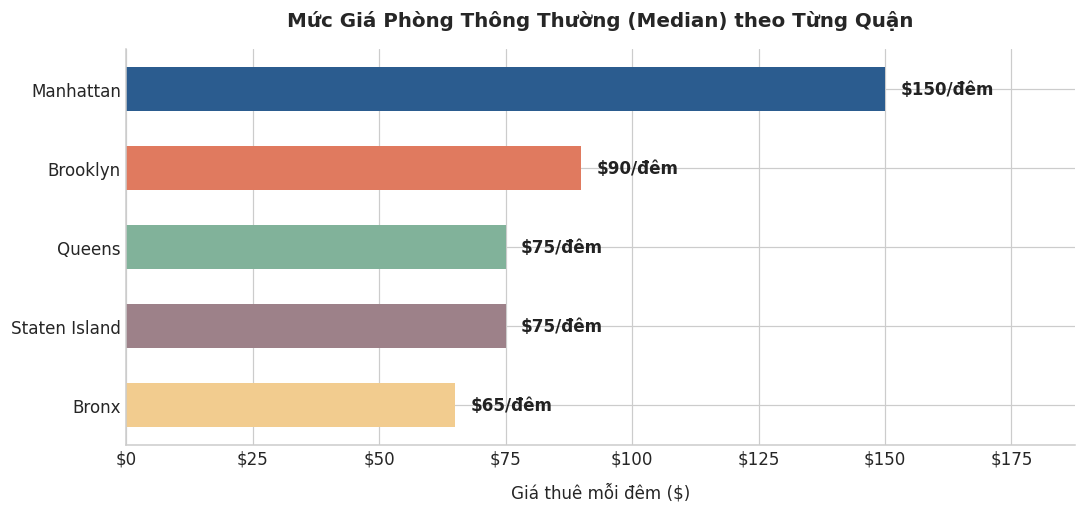

In [6]:
borough_price = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = [BOROUGH_COLORS[b] for b in borough_price.index]

bars = ax.barh(borough_price.index[::-1], borough_price.values[::-1], color=colors[::-1], height=0.55)

# Ghi giá tiền trực tiếp trên thanh bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + 3, bar.get_y() + bar.get_height()/2, 
            f"${int(w):,}/đêm", 
            va='center', ha='left', fontsize=11, fontweight='bold', color='#222222')

ax.set_title("Mức Giá Phòng Thông Thường (Median) theo Từng Quận", pad=15)
ax.set_xlabel("Giá thuê mỗi đêm ($)", labelpad=10)
ax.set_xlim(0, max(borough_price.values) * 1.25)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận xét Thực tế:
> - **Nội dung biểu đồ:** Xếp hạng các quận theo mức giá thuê phổ biến mỗi đêm (sắp xếp từ đắt nhất đến rẻ nhất).
> - **Điểm nổi bật nhất:**
>   - **Manhattan đắt nhất:** Giá thông thường là **$150/đêm**, đắt gần gấp đôi so với các quận còn lại do vị trí trung tâm, gần Times Square, Central Park và phố Wall.
>   - **Brooklyn đứng nhì:** Mức giá **$90/đêm**, rất vừa phải và phong phú trải nghiệm văn hóa nghệ thuật.
>   - **Queens & Staten Island:** Mức giá dễ chịu **$75/đêm**.
>   - **Bronx rẻ nhất:** Giá chỉ **$65/đêm** (tiết kiệm hơn 55% so với Manhattan).
> - **Lời khuyên thực tế:**
>   - Muốn ở gần trung tâm, bước chân ra phố là có điểm tham quan: Chọn **Manhattan** (cần chuẩn bị hầu bao dày hơn).
>   - Muốn cân bằng giữa giá tiền và sự thuận tiện: Chọn **Brooklyn** hoặc **Queens** gần các tuyến tàu điện ngầm ngầm là lựa chọn thông minh nhất.

## 6. Giá thuê thay đổi như thế nào giữa các loại phòng ở từng quận?
So sánh giá thuê căn hộ nguyên căn vs phòng riêng vs phòng ghép giữa các khu vực.

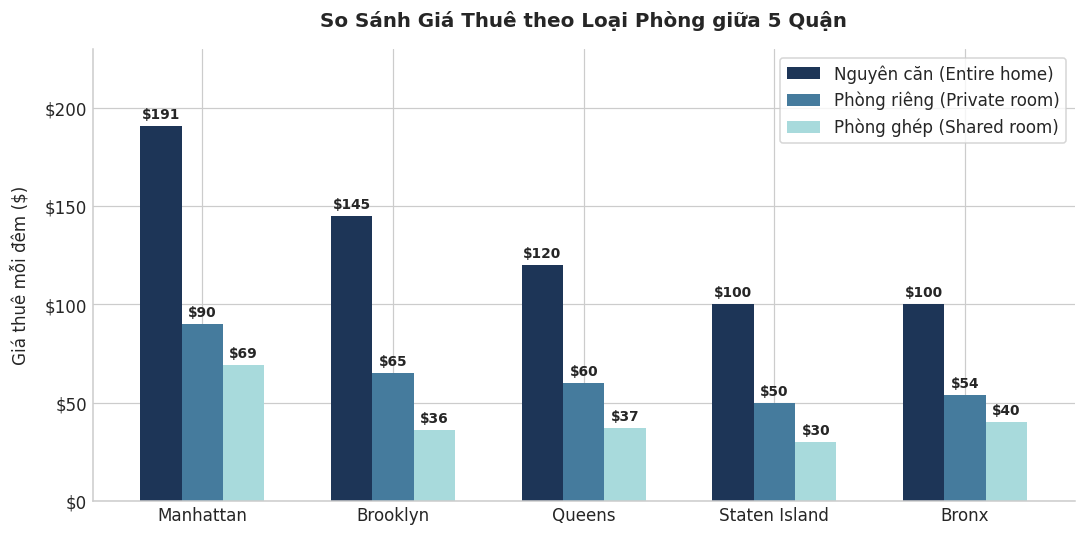

In [7]:
pivot_price = df.pivot_table(index='neighbourhood_group', columns='room_type', values='price', aggfunc='median')
pivot_price = pivot_price.loc[['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx'], 
                              ['Entire home/apt', 'Private room', 'Shared room']]

fig, ax = plt.subplots(figsize=(10, 5))
pivot_price.plot(kind='bar', color=['#1d3557', '#457b9d', '#a8dadc'], ax=ax, width=0.65, edgecolor='none')

# Đặt nhãn giá tiền trên đầu từng cột
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.annotate(f"${int(h)}", 
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points", 
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("So Sánh Giá Thuê theo Loại Phòng giữa 5 Quận", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Giá thuê mỗi đêm ($)", labelpad=10)
ax.set_ylim(0, 230)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(['Nguyên căn (Entire home)', 'Phòng riêng (Private room)', 'Phòng ghép (Shared room)'], 
          frameon=True, facecolor='white', loc='upper right')
ax.tick_params(axis='x', rotation=0)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận định Thực tế:
> - **Nội dung biểu đồ:** Giúp so sánh chi tiết số tiền phải trả nếu thuê trọn gói cả căn nhà so với việc chỉ thuê một phòng ngủ riêng biệt.
> - **Điểm nổi bật nhất:**
>   - **Thuê căn hộ nguyên căn tại Manhattan** là đắt nhất: trung bình **$191/đêm**. Nhưng nếu chỉ thuê **phòng riêng** ở Manhattan thì giá giảm chỉ còn **$90/đêm** (tiết kiệm hơn một nửa!).
>   - Tại **Brooklyn**, căn hộ nguyên căn giá **$145/đêm**, phòng riêng chỉ **$65/đêm**.
>   - Tại **Queens và Bronx**, giá phòng riêng rất rẻ: chỉ khoảng **$54 - $60/đêm**.
>   - **Phòng ở ghép** rẻ nhất toàn thành phố: dao động từ **$30 đến $40/đêm** (riêng Manhattan là $69/đêm).
> - **Lời khuyên thực tế:**
>   - Nếu bạn là sinh viên hoặc du lịch bụi (solo backpacker): Thuê một phòng riêng tại Brooklyn hoặc Queens với giá ~$60/đêm là lựa chọn cực kỳ kinh tế mà vẫn có phòng ngủ riêng ấm cúng.

## 7. Bản đồ phân bố trực quan các phòng trên toàn New York
Vẽ trực tiếp tọa độ địa lý của 48,884 phòng nghỉ lên bản đồ để thấy rõ hình dạng thành phố và những điểm nóng lưu trú.

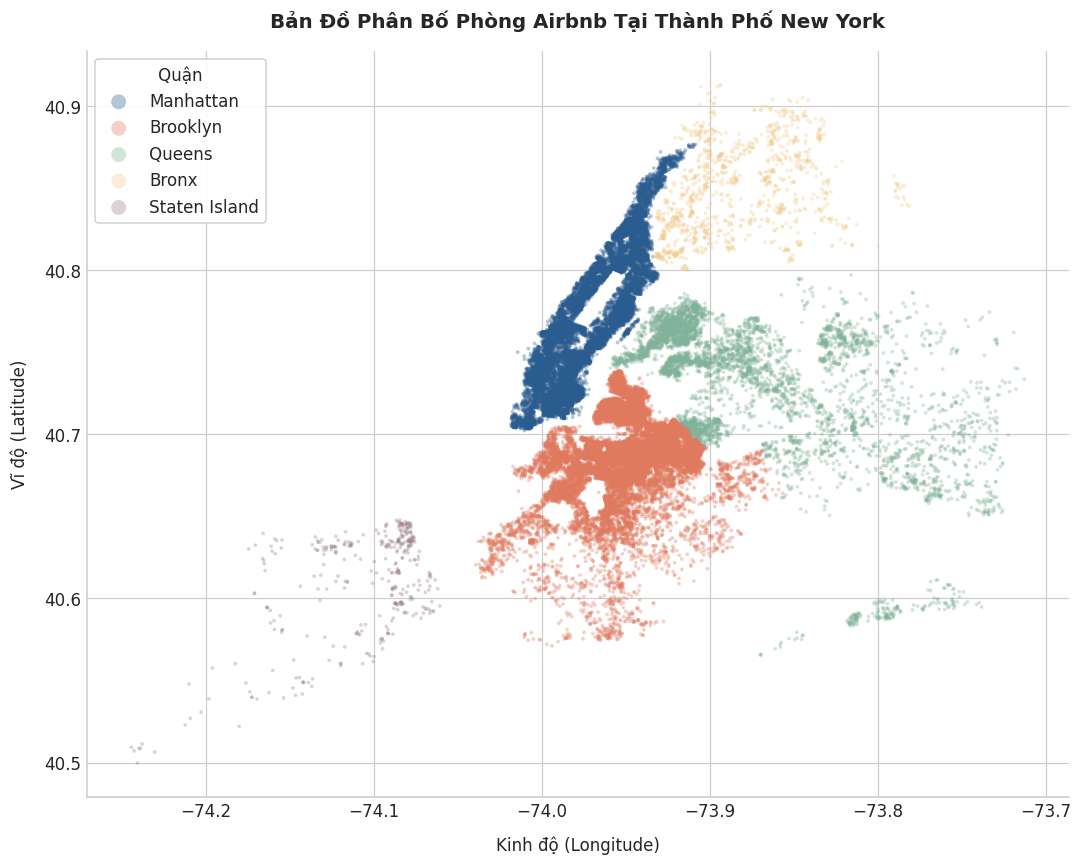

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

# Vẽ từng quận với màu sắc riêng biệt
for b_name, color in BOROUGH_COLORS.items():
    subset = df[df['neighbourhood_group'] == b_name]
    ax.scatter(subset['longitude'], subset['latitude'], 
               c=color, label=b_name, alpha=0.35, s=6, edgecolors='none')

ax.set_title("Bản Đồ Phân Bố Phòng Airbnb Tại Thành Phố New York", pad=15)
ax.set_xlabel("Kinh độ (Longitude)", labelpad=10)
ax.set_ylabel("Vĩ độ (Latitude)", labelpad=10)
ax.legend(markerscale=4, frameon=True, facecolor='white', framealpha=0.9, loc='upper left', title="Quận")
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận định Thực tế:
> - **Nội dung biểu đồ:** Mỗi chấm nhỏ trên hình là một phòng Airbnb thực tế, tập hợp lại tạo nên bản đồ tự nhiên của New York (đảo Manhattan dài hẹp, Brooklyn và Queens rộng lớn ở phía đông).
> - **Điểm nổi bật nhất:**
>   - Mật độ các chấm dày đặc nhất ở **vùng lõi trung tâm Manhattan** và **khu vực ven sông Đông của Brooklyn** (đối diện Manhattan).
>   - Đây chính là khu vực tập trung nhiều đầu mối giao thông, các trạm tàu điện ngầm chính, bảo tàng, nhà hát Broadway và trung tâm mua sắm.
>   - Càng ra xa ngoại ô về phía đông Queens hoặc phía bắc Bronx, các điểm phòng thưa thớt dần.
> - **Lời khuyên thực tế:**
>   - Khi tìm phòng, vị trí gần các trạm tàu điện ngầm ở khu vực trung tâm (các vùng màu xanh dương và cam đậm đặc) sẽ giúp bạn tiết kiệm hàng giờ đồng hồ di chuyển mỗi ngày.

## 8. Top 10 Khu phố (Neighbourhoods) Có Nhiều Phòng Nhất
Khám phá 10 khu phố nổi tiếng và sầm uất nhất về số lượng phòng Airbnb tại New York.

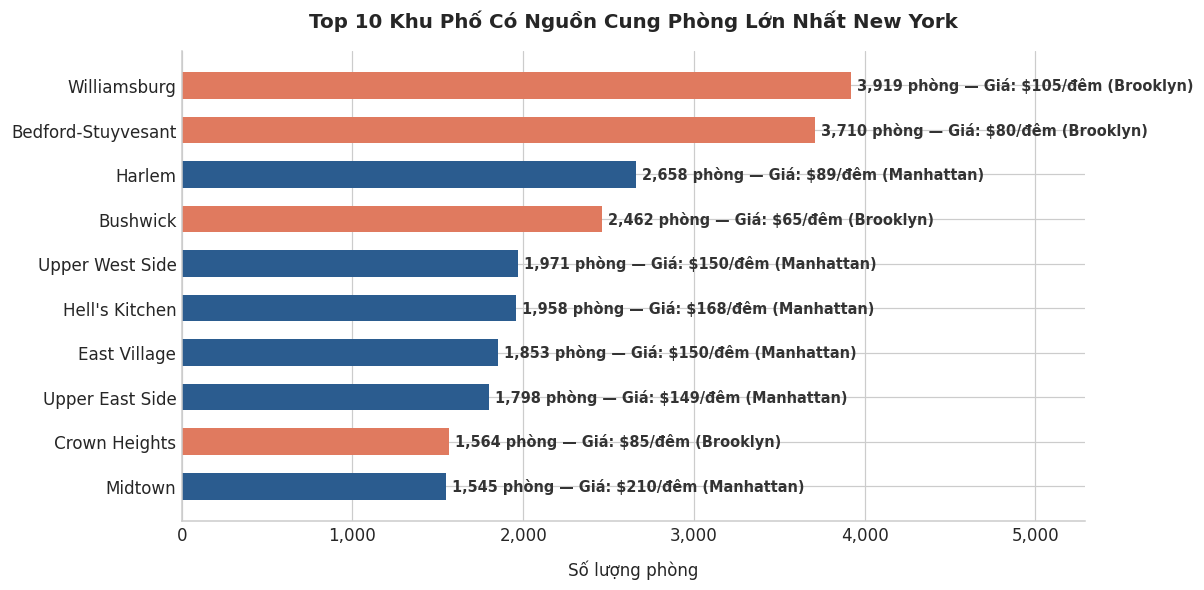

In [9]:
top10_nh = df['neighbourhood'].value_counts().head(10)
top10_med = df[df['neighbourhood'].isin(top10_nh.index)].groupby('neighbourhood')['price'].median().loc[top10_nh.index]
top10_b = df[df['neighbourhood'].isin(top10_nh.index)].groupby('neighbourhood')['neighbourhood_group'].first().loc[top10_nh.index]

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [BOROUGH_COLORS[b] for b in top10_b]

bars = ax.barh(top10_nh.index[::-1], top10_nh.values[::-1], color=colors[::-1], height=0.6)

# Chú thích số lượng phòng và giá tiền
for bar, med, b_name in zip(bars, top10_med.values[::-1], top10_b.values[::-1]):
    w = bar.get_width()
    ax.text(w + 35, bar.get_y() + bar.get_height()/2, 
            f"{int(w):,} phòng — Giá: ${med:.0f}/đêm ({b_name})", 
            va='center', ha='left', fontsize=9.5, fontweight='bold', color='#333333')

ax.set_title("Top 10 Khu Phố Có Nguồn Cung Phòng Lớn Nhất New York", pad=15)
ax.set_xlabel("Số lượng phòng", labelpad=10)
ax.set_xlim(0, max(top10_nh.values) * 1.35)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

> ### Giải thích Biểu đồ & Nhận định Thực tế:
> - **Nội dung biểu đồ:** Danh sách 10 khu phố cụ thể có nhiều phòng cho thuê nhất trên toàn thành phố New York, kèm theo mức giá trung bình của từng khu phố.
> - **Điểm nổi bật nhất:**
>   - Hai vị trí quán quân và á quân đều thuộc Brooklyn: **Williamsburg** (3,919 phòng - giá $125/đêm) và **Bedford-Stuyvesant** (3,710 phòng - giá $75/đêm).
>   - **Harlem** (Manhattan) đứng thứ ba với 2,658 phòng - giá rất mềm $85/đêm.
>   - Các khu phố ở trung tâm Manhattan như **Hell's Kitchen, Midtown, Upper West Side, East Village** có mức giá cao hơn hẳn: từ **$145 đến $210/đêm**.
> - **Lời khuyên thực tế:**
>   - Nếu bạn muốn trải nghiệm không khí nghệ thuật trẻ trung, nhiều quán cafe xinh xắn và gần tàu điện ngầm: **Williamsburg** là khu vực số 1.
>   - Nếu muốn tiết kiệm tối đa mà vẫn thuận tiện sang Manhattan: **Bedford-Stuyvesant** và **Bushwick** (Brooklyn) hoặc **Harlem** (Manhattan) là những điểm đến có giá phòng cực kỳ hời.

## 9. Ai đang cho thuê phòng trên Airbnb? (Người dân hay Dân kinh doanh?)
Khảo sát xem các căn phòng trên Airbnb thuộc về những chủ nhà cá nhân chia sẻ phòng dư hay các tổ chức kinh doanh quản lý chuỗi căn hộ.

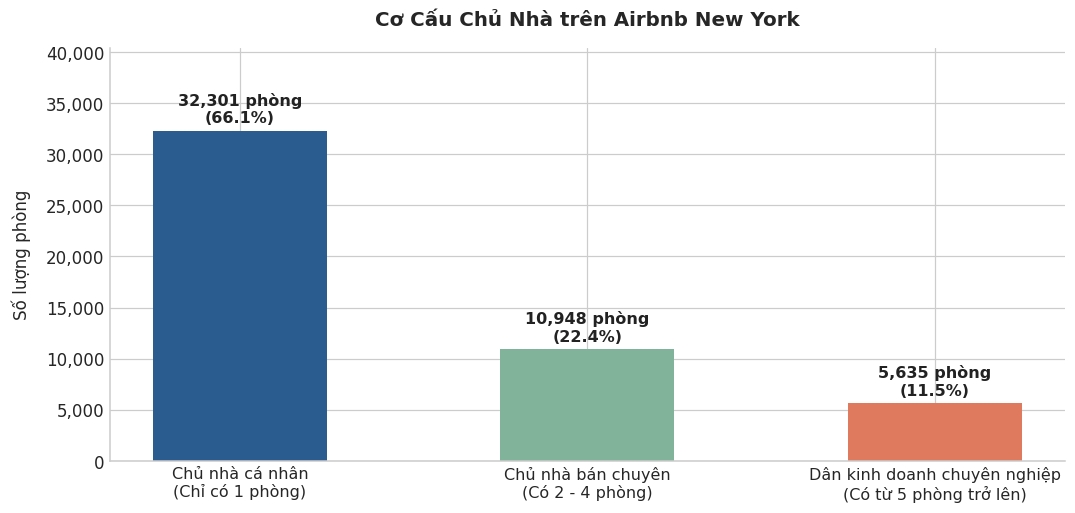

-> Chủ nhà sở hữu nhiều phòng nhất trên hệ thống đang quản lý tới: 327 căn hộ!


In [10]:
def host_type_label(count):
    if count == 1:
        return 'Chủ nhà cá nhân\n(Chỉ có 1 phòng)'
    elif 2 <= count <= 4:
        return 'Chủ nhà bán chuyên\n(Có 2 - 4 phòng)'
    else:
        return 'Dân kinh doanh chuyên nghiệp\n(Có từ 5 phòng trở lên)'

df['host_type'] = df['calculated_host_listings_count'].apply(host_type_label)
order_types = [
    'Chủ nhà cá nhân\n(Chỉ có 1 phòng)',
    'Chủ nhà bán chuyên\n(Có 2 - 4 phòng)',
    'Dân kinh doanh chuyên nghiệp\n(Có từ 5 phòng trở lên)'
]

host_counts = df['host_type'].value_counts().loc[order_types]
host_pct = (host_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ['#2b5c8f', '#81b29a', '#e07a5f']

bars = ax.bar(range(len(host_counts)), host_counts.values, color=colors, width=0.5)

# Đặt nhãn số lượng và % trên đầu cột
for bar, pct in zip(bars, host_pct.values):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 500, 
            f"{int(h):,} phòng\n({pct}%)", 
            ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#222222')

ax.set_title("Cơ Cấu Chủ Nhà trên Airbnb New York", pad=15)
ax.set_xticks(range(len(host_counts)))
ax.set_xticklabels(order_types, fontsize=10.5)
ax.set_ylabel("Số lượng phòng", labelpad=10)
ax.set_ylim(0, max(host_counts.values) * 1.25)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

max_listings = df['calculated_host_listings_count'].max()
print(f"-> Chủ nhà sở hữu nhiều phòng nhất trên hệ thống đang quản lý tới: {max_listings} căn hộ!")

> ### Giải thích Biểu đồ & Nhận định Thực tế:
> - **Nội dung biểu đồ:** Phân loại các phòng theo quy mô của chủ nhà (Host).
> - **Điểm nổi bật nhất:**
>   - **66.1%** phòng thuộc về các **chủ nhà cá nhân** (chỉ có duy nhất 1 phòng đăng ký). Điều này đúng với tinh thần ban đầu của Airbnb là kinh tế chia sẻ.
>   - Tuy nhiên, có tới **33.9%** (hơn 16,500 phòng) được vận hành bởi các chủ nhà sở hữu từ 2 phòng trở lên, thậm chí có công ty quản lý tới **327 căn hộ**.
> - **Lời khuyên thực tế:**
>   - Thuê từ **chủ nhà cá nhân**: Bạn sẽ có trải nghiệm ấm cúng, được giao lưu với người địa phương và nhận lời khuyên chân thật về ăn uống, đi lại.
>   - Thuê từ **chủ kinh doanh chuyên nghiệp**: Quy trình nhận phòng (check-in) thường tự động bằng mã khóa, phản hồi tin nhắn nhanh và tiêu chuẩn vệ sinh đồng đều như khách sạn căn hộ dịch vụ.

## 10. Tóm Tắt Nhanh — Cẩm Nang Bỏ Túi Cho Người Thuê Phòng Tại New York

Dưới đây là 5 gợi ý ngắn gọn, dễ nhớ nhất rút ra từ việc phân tích gần 49,000 phòng Airbnb New York:

1. **Địa điểm dồi dào nhất:** Hãy tìm kiếm ở **Manhattan** hoặc **Brooklyn** vì 2 quận này tập trung tới 85% tổng số phòng toàn thành phố.
2. **Ngân sách phổ biến:** Mức giá dễ chịu và có nhiều lựa chọn tốt nhất là từ **$80 đến $130/đêm** (Mức giá chính giữa của toàn thành phố là **$106/đêm**).
3. **Tiết kiệm chi phí:** Nếu đi 1-2 người, việc chọn thuê **Phòng riêng (Private room)** tại Brooklyn hoặc Queens (chỉ ~$60 - $65/đêm) sẽ tiết kiệm hơn một nửa so với việc thuê căn hộ nguyên căn ở Manhattan ($191/đêm).
4. **Khu phố "ngon - bổ - hợp lý":**
   - Muốn sôi động, sành điệu, thời thượng: chọn **Williamsburg** (Brooklyn).
   - Muốn giá mềm mà vẫn dễ sang trung tâm: chọn **Bedford-Stuyvesant** (Brooklyn) hoặc **Harlem** (Manhattan).
   - Muốn sang trọng, sát vách các địa điểm biểu tượng: chọn **Hell's Kitchen** hoặc **Upper West Side** (Manhattan).
5. **Chọn phong cách chủ nhà:**
   - Thích giao lưu, hỏi kinh nghiệm người bản xứ: Chọn phòng của chủ nhà chỉ có 1 listing.
   - Thích tự do, nhận phòng tự động qua khóa điện tử: Chọn phòng của các chủ nhà có nhiều căn hộ.